# Klaszterezés és az EM algoritmus

**Emlékeztető.** EM-alapú klaszterezésnél az ELBO a következőképpen nézett ki:

\begin{align}
\mathcal{L} (\pi,\mu,\Sigma) = \sum_i \sum_k \gamma_{ik} \left( \ln \pi_k + \ln \mathcal{N}(\mathbf{x}_i | \mu_k, \Sigma_k ) \right) ,
\end{align}

ahol $i$ a minták száma, $k$ a klaszterek száma, $\gamma_{ik}$ a responsibility értékek, $\pi_k$ a $k$. klaszter *a priori* valószínűsége, $\mu_k$ a $k$. klaszter középpontja, $\Sigma_k$ pedig a $k$. klaszter "kiterjedése". A klaszterezés során az ELBO-t szeretnénk maximalizálni, ezt így tesszük:

0. Inicializáció véletlen $\mu_k$, $\Sigma_k$ és $\pi_k$ paraméterekkel (mindegyikből annyi, ahány klaszter van).
1. E-lépés: frissítjük $\gamma$-t, azaz
\begin{align*}
\gamma_{ik} &= \frac{\pi_k \mathcal{N}(\mathbf{x}_i | \mu_k, \Sigma_k)}{\sum_k \pi_k \mathcal{N}(\mathbf{x}_i | \mu_k, \Sigma_k)},\\
N_k &= \sum_i \gamma_{ik}.
\end{align*}
2. M-lépés: frissítjük a többi paramétert, azaz minden $k$-ra
\begin{align*}
\Sigma_k &= \frac{1}{N_k} \sum_i \gamma_{ik} (\mathbf{x}_i-\mu_k)(\mathbf{x}_i-\mu_k)^T,\\
\mu_k &= \frac{1}{N_k} \sum_i \gamma_{ik} \mathbf{x}_i,\\
\pi_k &= \frac{N_k}{N}.
\end{align*}
3. E- és M-lépések ismétlése.


In [2]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import multivariate_normal

**0. feladat.** A lenti kóddal generálj és ábrázolj egy adathalmazt.

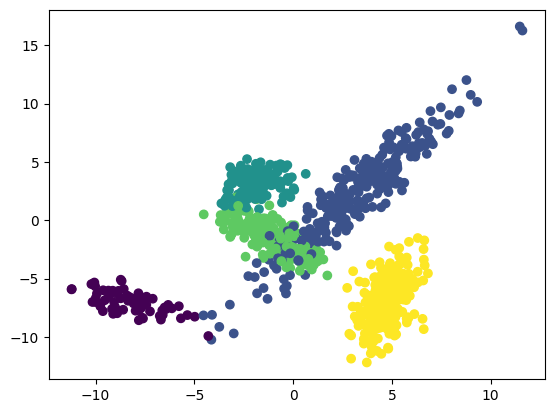

In [3]:
def generate_data(N,K):
  mu,sg = [],[]
  for k in range(K):
    mu += [np.random.randn(2)*5]
    ss = np.random.randn(2,2)
    sg += [ss.T@ss + np.eye(2)/2]

  pi = np.random.rand(K)
  pi = pi/sum(pi)
  X,Z = [],[]
  for i in range(N):
    k = np.random.choice(np.arange(K),p=pi)
    X += [multivariate_normal.rvs(mu[k],sg[k])]
    Z += [k]
  X = np.row_stack(X)
  return X,Z,np.vstack(mu),sg,pi

X,Z_,mu_,sg_,pi_ = generate_data(1000,5)
plt.scatter(X[:,0],X[:,1],c=Z_);

**1. feladat.** Implementáld a fenti algoritmust! Törekedj az egyszerűségre, mátrix-vektor műveletek használatára! (A feladat kb. 15 sorból megoldható.) A normális eloszlásnál érdemes a `scipy` megfelelő függvényét használni, azaz pl.

$$\mathcal{N}(\mathbf{x} | \mu_k, \Sigma_k)$$ valahogy így írható:

`multivariate_normal.pdf(X,mean=mu[k],cov=sg[k])`

In [4]:
D = 2 # minták dimenziója
K = 5 # klaszterek száma

pi = np.ones(K)/K # a priori klasztervalószínűségek
mu = np.random.randn(K,D) # klaszterközéppontok
sg = [np.eye(D) for k in range(K)] # klaszter-kovarianciák

# EM-algoritmus (1000 iteráció)
for i in range(1000):
  pass

**2. feladat.** Ábrázold a kiakakuló klasztereket! Az ábrán jelenjenek meg a pontok (klaszterenként különböző színekkel), valamint az illesztett komponensek szintvonalai (érdemes a naiv Bayes gyakorlatról kipuskázni az ábrázolást).

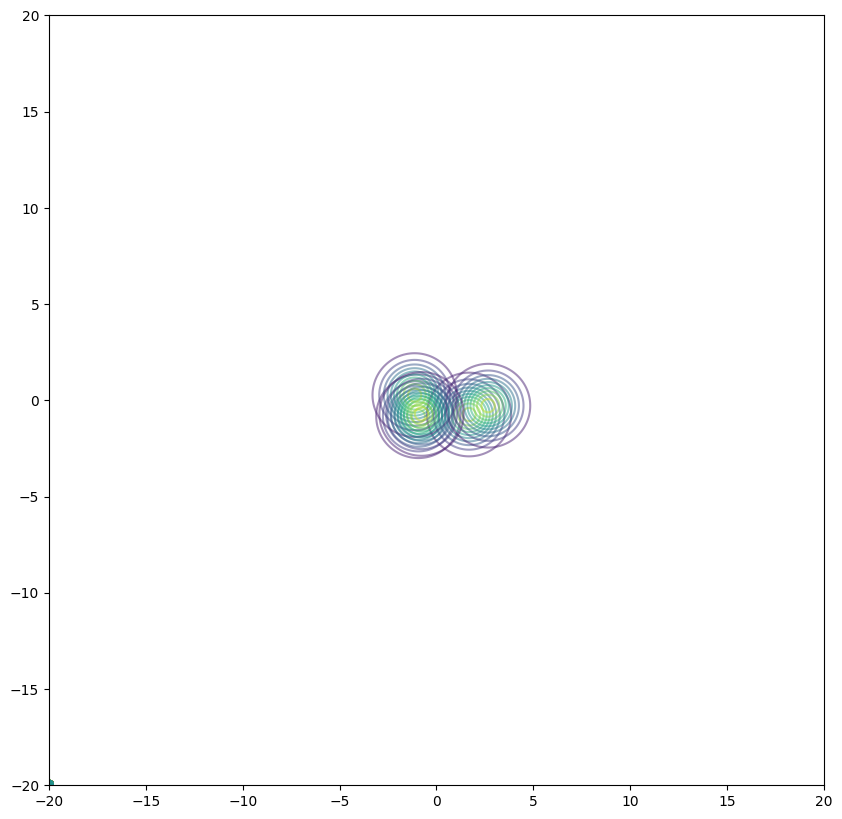

In [7]:
# prompt: 2. feladat. Ábrázold a kiakakuló klasztereket! Az ábrán jelenjenek meg a pontok (klaszterenként különböző színekkel), valamint az illesztett komponensek szintvonalai (érdemes a naiv Bayes gyakorlatról kipuskázni az ábrázolást).

from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import multivariate_normal

# ... (previous code)

# 2. feladat: Klaszterek ábrázolása
x = np.linspace(-20, 20, 1000)
y = np.linspace(-20, 20, 1000)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

for k in range(K):
    rv = multivariate_normal(mean=mu[k], cov=sg[k])
    ax.contour(X, Y, rv.pdf(pos), levels=10, alpha=0.5)

ax.scatter(X[:,0], X[:,1], c=Z_)
plt.show()

**3. feladat.** Értékeld ki a megoldást a következők alapján:

- Prediktált és valódi klaszterezés együttjárása (`sklearn.metrics.adjusted_rand_score`)
- Klaszterközéppontok eltérése a valódi klaszterközéppontoktól (plot)

A kiértékelést végezd el több véletlenszerűen generált adathalmazon is. Mit tapasztalsz?